In [1]:
import pandas as pd
import os
import re

In [2]:
data_path = "../data/raw/"
files = [f for f in os.listdir(data_path) if f.endswith(('.xlsx', '.xls'))]
print(f"Total files found: {len(files)}")
for f in sorted(files):
    print(f)

Total files found: 0


In [7]:
import os

print("Current working directory:", os.getcwd())
print()
print("Does '../data/raw/' exist?", os.path.exists("../data/raw/"))
print()
print("Contents of current directory:")
print(os.listdir("."))

Current working directory: c:\Users\merye\OneDrive\INRAT_PROJECT\inrat_beja_pipeline\notebooks

Does '../data/raw/' exist? True

Contents of current directory:
['01_exploration.ipynb']


In [8]:
print("Everything inside data/raw/:")
print(os.listdir("../data/raw/"))

Everything inside data/raw/:
['indices_nuages_carioka.csv', 'indices_nuages_dhahbi2.csv', 'indices_nuages_dhahbi3.csv', 'indices_nuages_dhahbi4.csv', 'indices_nuages_dhahbi5.csv', 'indices_nuages_dhahbi6.csv', 'indices_nuages_dhahbi7.csv', 'indices_nuages_inrat100.csv', 'indices_nuages_inrat100_1.csv', 'indices_nuages_inrat100_2.csv', 'indices_nuages_karim.csv', 'indices_nuages_karim1.csv', 'indices_nuages_khiar.csv', 'indices_nuages_khiar1.csv', 'indices_nuages_khiar2.csv', 'indices_nuages_khiar3.csv', 'indices_nuages_khiar4.csv', 'indices_nuages_khiar5.csv', 'indices_nuages_maali.csv', 'indices_nuages_maali1.csv', 'indices_nuages_maali2.csv', 'indices_nuages_maali3.csv', 'indices_nuages_maali4.csv', 'indices_nuages_maali5.csv', 'indices_nuages_salim.csv', 'indices_nuages_salim1.csv', 'indices_nuages_salim2.csv', 'indices_nuages_salim3.csv', 'indices_nuages_saragola.csv']


In [3]:
data_path = "../data/raw/"
files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
print(f"Total files found: {len(files)}")
for f in sorted(files):
    print(f)

Total files found: 29
indices_nuages_carioka.csv
indices_nuages_dhahbi2.csv
indices_nuages_dhahbi3.csv
indices_nuages_dhahbi4.csv
indices_nuages_dhahbi5.csv
indices_nuages_dhahbi6.csv
indices_nuages_dhahbi7.csv
indices_nuages_inrat100.csv
indices_nuages_inrat100_1.csv
indices_nuages_inrat100_2.csv
indices_nuages_karim.csv
indices_nuages_karim1.csv
indices_nuages_khiar.csv
indices_nuages_khiar1.csv
indices_nuages_khiar2.csv
indices_nuages_khiar3.csv
indices_nuages_khiar4.csv
indices_nuages_khiar5.csv
indices_nuages_maali.csv
indices_nuages_maali1.csv
indices_nuages_maali2.csv
indices_nuages_maali3.csv
indices_nuages_maali4.csv
indices_nuages_maali5.csv
indices_nuages_salim.csv
indices_nuages_salim1.csv
indices_nuages_salim2.csv
indices_nuages_salim3.csv
indices_nuages_saragola.csv


In [5]:
def extract_variety(filename):
    name = filename.replace('.xlsx', '').replace('.xls', '')
    name = name.replace('indices_nuages_', '')
    variety = re.sub(r'(_?\d+)$', '', name)
    return variety

In [6]:
all_dfs = []

for f in files:
    try:
        df = pd.read_csv(data_path + f)
        df['variety'] = extract_variety(f)
        df['source_file'] = f
        all_dfs.append(df)
    except Exception as e:
        print(f"ERROR loading {f}: {type(e).__name__}: {e}")

print(f"Successfully loaded: {len(all_dfs)} files")

Successfully loaded: 29 files


In [7]:
master_df = pd.concat(all_dfs, ignore_index=True)

print(f"Total rows: {len(master_df)}")
print(f"Varieties found: {sorted(master_df['variety'].unique())}")
print(master_df['variety'].value_counts())

Total rows: 1368
Varieties found: ['carioka.csv', 'dhahbi2.csv', 'dhahbi3.csv', 'dhahbi4.csv', 'dhahbi5.csv', 'dhahbi6.csv', 'dhahbi7.csv', 'inrat100.csv', 'inrat100_1.csv', 'inrat100_2.csv', 'karim.csv', 'karim1.csv', 'khiar.csv', 'khiar1.csv', 'khiar2.csv', 'khiar3.csv', 'khiar4.csv', 'khiar5.csv', 'maali.csv', 'maali1.csv', 'maali2.csv', 'maali3.csv', 'maali4.csv', 'maali5.csv', 'salim.csv', 'salim1.csv', 'salim2.csv', 'salim3.csv', 'saragola.csv']
variety
maali.csv         696
carioka.csv        24
khiar3.csv         24
salim3.csv         24
salim2.csv         24
salim1.csv         24
salim.csv          24
maali5.csv         24
maali4.csv         24
maali3.csv         24
maali2.csv         24
maali1.csv         24
khiar5.csv         24
khiar4.csv         24
khiar2.csv         24
dhahbi2.csv        24
khiar1.csv         24
khiar.csv          24
karim1.csv         24
karim.csv          24
inrat100_2.csv     24
inrat100_1.csv     24
inrat100.csv       24
dhahbi7.csv        24
dhahbi6.

In [8]:
# test the function in isolation
print(extract_variety("dhahbi2.csv"))
print(extract_variety("inrat100_1.csv"))
print(extract_variety("maali.csv"))

dhahbi2.csv
inrat100_1.csv
maali.csv


In [9]:
def extract_variety_test(filename):
    print(f"Input: {filename}")
    
    name = filename.replace('.csv', '')
    print(f"After removing .csv: {name}")
    
    name = name.replace('indices_nuages_', '')
    print(f"After removing prefix: {name}")
    
    variety = re.sub(r'(_?\d+)$', '', name)
    print(f"After regex: {variety}")
    
    return variety

result = extract_variety_test("dhahbi2.csv")
print(f"Final result: {result}")

Input: dhahbi2.csv
After removing .csv: dhahbi2
After removing prefix: dhahbi2
After regex: dhahbi
Final result: dhahbi


RE-DO

In [1]:
# Cell 1
import pandas as pd
import os
import re

In [2]:
# Cell 2
data_path = "../data/raw/"
files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
print(f"Total files found: {len(files)}")

Total files found: 29


In [3]:
# Cell 3
def extract_variety(filename):
    name = filename.replace('.csv', '')
    name = name.replace('indices_nuages_', '')
    variety = re.sub(r'(_?\d+)$', '', name)
    return variety

# test immediately, right here, before moving on
print(extract_variety("dhahbi2.csv"))
print(extract_variety("inrat100_1.csv"))
print(extract_variety("maali.csv"))

dhahbi
inrat100
maali


In [4]:
# Cell 4
all_dfs = []

for f in files:
    try:
        df = pd.read_csv(data_path + f)
        df['variety'] = extract_variety(f)
        df['source_file'] = f
        all_dfs.append(df)
    except Exception as e:
        print(f"ERROR loading {f}: {type(e).__name__}: {e}")

print(f"Successfully loaded: {len(all_dfs)} files")

Successfully loaded: 29 files


In [5]:
# Cell 5
master_df = pd.concat(all_dfs, ignore_index=True)

print(f"Total rows: {len(master_df)}")
print(f"Varieties found: {sorted(master_df['variety'].unique())}")
print(master_df['variety'].value_counts())

Total rows: 1368
Varieties found: ['carioka', 'dhahbi', 'inrat', 'inrat100', 'karim', 'khiar', 'maali', 'salim', 'saragola']
variety
maali       816
dhahbi      144
khiar       144
salim        96
inrat100     48
karim        48
carioka      24
inrat        24
saragola     24
Name: count, dtype: int64


In [6]:
maali_rows = master_df[master_df['variety'] == 'maali']
print(f"Total maali rows: {len(maali_rows)}")
print(maali_rows['source_file'].value_counts())

Total maali rows: 816
source_file
indices_nuages_maali.csv     696
indices_nuages_maali1.csv     24
indices_nuages_maali2.csv     24
indices_nuages_maali3.csv     24
indices_nuages_maali4.csv     24
indices_nuages_maali5.csv     24
Name: count, dtype: int64


In [7]:
master_df = pd.concat(all_dfs, ignore_index=True)

print(f"Total rows: {len(master_df)}")
print(f"Varieties found: {sorted(master_df['variety'].unique())}")
print()
print("Rows per variety:")
print(master_df['variety'].value_counts())
print()
print("Files per variety:")
print(master_df.groupby('variety')['source_file'].nunique())

Total rows: 1368
Varieties found: ['carioka', 'dhahbi', 'inrat', 'inrat100', 'karim', 'khiar', 'maali', 'salim', 'saragola']

Rows per variety:
variety
maali       816
dhahbi      144
khiar       144
salim        96
inrat100     48
karim        48
carioka      24
inrat        24
saragola     24
Name: count, dtype: int64

Files per variety:
variety
carioka     1
dhahbi      6
inrat       1
inrat100    2
karim       2
khiar       6
maali       6
salim       4
saragola    1
Name: source_file, dtype: int64


In [8]:
# check what files fall under "inrat" vs "inrat100"
print(master_df[master_df['variety'] == 'inrat']['source_file'].unique())
print(master_df[master_df['variety'] == 'inrat100']['source_file'].unique())

['indices_nuages_inrat100.csv']
['indices_nuages_inrat100_1.csv' 'indices_nuages_inrat100_2.csv']


In [9]:
def extract_variety(filename):
    name = filename.replace('.csv', '')
    name = name.replace('indices_nuages_', '')
    
    # Known variety names that genuinely contain a number — don't strip these
    protected_names = ['inrat100']
    
    if name in protected_names:
        return name
    
    variety = re.sub(r'(_?\d+)$', '', name)
    
    # also check if stripping created a protected name's "broken" version
    # e.g. inrat100_1 -> should become inrat100, not inrat
    for protected in protected_names:
        if variety == protected.rstrip('0123456789'):
            return protected
    
    return variety

In [10]:
def extract_variety(filename):
    name = filename.replace('.csv', '')
    name = name.replace('indices_nuages_', '')
    
    protected_names = ['inrat100']
    
    # if the name starts with a protected variety name, use that protected name
    for protected in protected_names:
        if name.startswith(protected):
            return protected
    
    # otherwise, strip trailing numbers as before
    variety = re.sub(r'(_?\d+)$', '', name)
    return variety

RE-DO


In [1]:
import pandas as pd
import os
import re

In [2]:
data_path = "../data/raw/"
files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
print(f"Total files found: {len(files)}")

Total files found: 29


In [3]:
def extract_variety(filename):
    name = filename.replace('.csv', '')
    name = name.replace('indices_nuages_', '')
    
    protected_names = ['inrat100']
    
    for protected in protected_names:
        if name.startswith(protected):
            return protected
    
    variety = re.sub(r'(_?\d+)$', '', name)
    return variety

In [4]:
all_dfs = []

for f in files:
    try:
        df = pd.read_csv(data_path + f)
        df['variety'] = extract_variety(f)
        df['source_file'] = f
        all_dfs.append(df)
    except Exception as e:
        print(f"ERROR loading {f}: {type(e).__name__}: {e}")

print(f"Successfully loaded: {len(all_dfs)} files")

Successfully loaded: 29 files


In [5]:
master_df = pd.concat(all_dfs, ignore_index=True)

print(f"Total rows: {len(master_df)}")
print()
print("Files per variety:")
print(master_df.groupby('variety')['source_file'].nunique())

Total rows: 1368

Files per variety:
variety
carioka     1
dhahbi      6
inrat100    3
karim       2
khiar       6
maali       6
salim       4
saragola    1
Name: source_file, dtype: int64


REEEEEEEEEEEEEEEEEEEEEEE-------------DOOOOOOOOOOOOOOOOOOOOOOOOOO4

In [10]:
#cell 1
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy import stats

In [11]:
#cell 2
data_path = "../data/raw/"
files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
print(f"Total files found: {len(files)}")

Total files found: 29


In [12]:
#cell 3
def extract_variety(filename):
    name = filename.replace('.csv', '')
    name = name.replace('indices_nuages_', '')
    
    protected_names = ['inrat100']
    for protected in protected_names:
        if name.startswith(protected):
            return protected
    
    variety = re.sub(r'(_?\d+)$', '', name)
    return variety

In [13]:
#cell 4
all_dfs = []

for f in files:
    try:
        df = pd.read_csv(data_path + f)
        df['variety'] = extract_variety(f)
        df['source_file'] = f
        all_dfs.append(df)
    except Exception as e:
        print(f"ERROR loading {f}: {type(e).__name__}: {e}")

print(f"Successfully loaded: {len(all_dfs)} files")

Successfully loaded: 29 files


In [14]:
#cell 5
master_df = pd.concat(all_dfs, ignore_index=True)

print(f"Total rows: {len(master_df)}")
print()
print("Files per variety:")
print(master_df.groupby('variety')['source_file'].nunique())

Total rows: 696

Files per variety:
variety
carioka     1
dhahbi      6
inrat100    3
karim       2
khiar       6
maali       6
salim       4
saragola    1
Name: source_file, dtype: int64


In [15]:
#cell 6
print("=== MASTER DATASET OVERVIEW ===")
print(f"Total rows: {len(master_df)}")
print(f"Total columns: {len(master_df.columns)}")
print(f"Wheat varieties: {sorted(master_df['variety'].unique())}")
print()
print("=== MISSING VALUES PER COLUMN ===")
for col in ['NDVI', 'EVI', 'NDRE', 'GNDVI', 'SAVI']:
    missing = master_df[col].isna().sum()
    pct = (missing / len(master_df)) * 100
    print(f"{col}: {missing} missing ({pct:.1f}%)")
print()
print("=== MISSING VALUES PER VARIETY ===")
for variety in sorted(master_df['variety'].unique()):
    subset = master_df[master_df['variety'] == variety]
    missing = subset['NDVI'].isna().sum()
    total = len(subset)
    pct = (missing / total) * 100
    print(f"{variety}: {missing}/{total} rows missing ({pct:.1f}%)")

=== MASTER DATASET OVERVIEW ===
Total rows: 696
Total columns: 9
Wheat varieties: ['carioka', 'dhahbi', 'inrat100', 'karim', 'khiar', 'maali', 'salim', 'saragola']

=== MISSING VALUES PER COLUMN ===
NDVI: 41 missing (5.9%)
EVI: 41 missing (5.9%)
NDRE: 41 missing (5.9%)
GNDVI: 41 missing (5.9%)
SAVI: 41 missing (5.9%)

=== MISSING VALUES PER VARIETY ===
carioka: 2/24 rows missing (8.3%)
dhahbi: 10/144 rows missing (6.9%)
inrat100: 3/72 rows missing (4.2%)
karim: 3/48 rows missing (6.2%)
khiar: 11/144 rows missing (7.6%)
maali: 6/144 rows missing (4.2%)
salim: 5/96 rows missing (5.2%)
saragola: 1/24 rows missing (4.2%)


C:\Users\merye\AppData\Local\Temp\ipykernel_31144\578516942.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(varieties, rotation=45, ha='right')


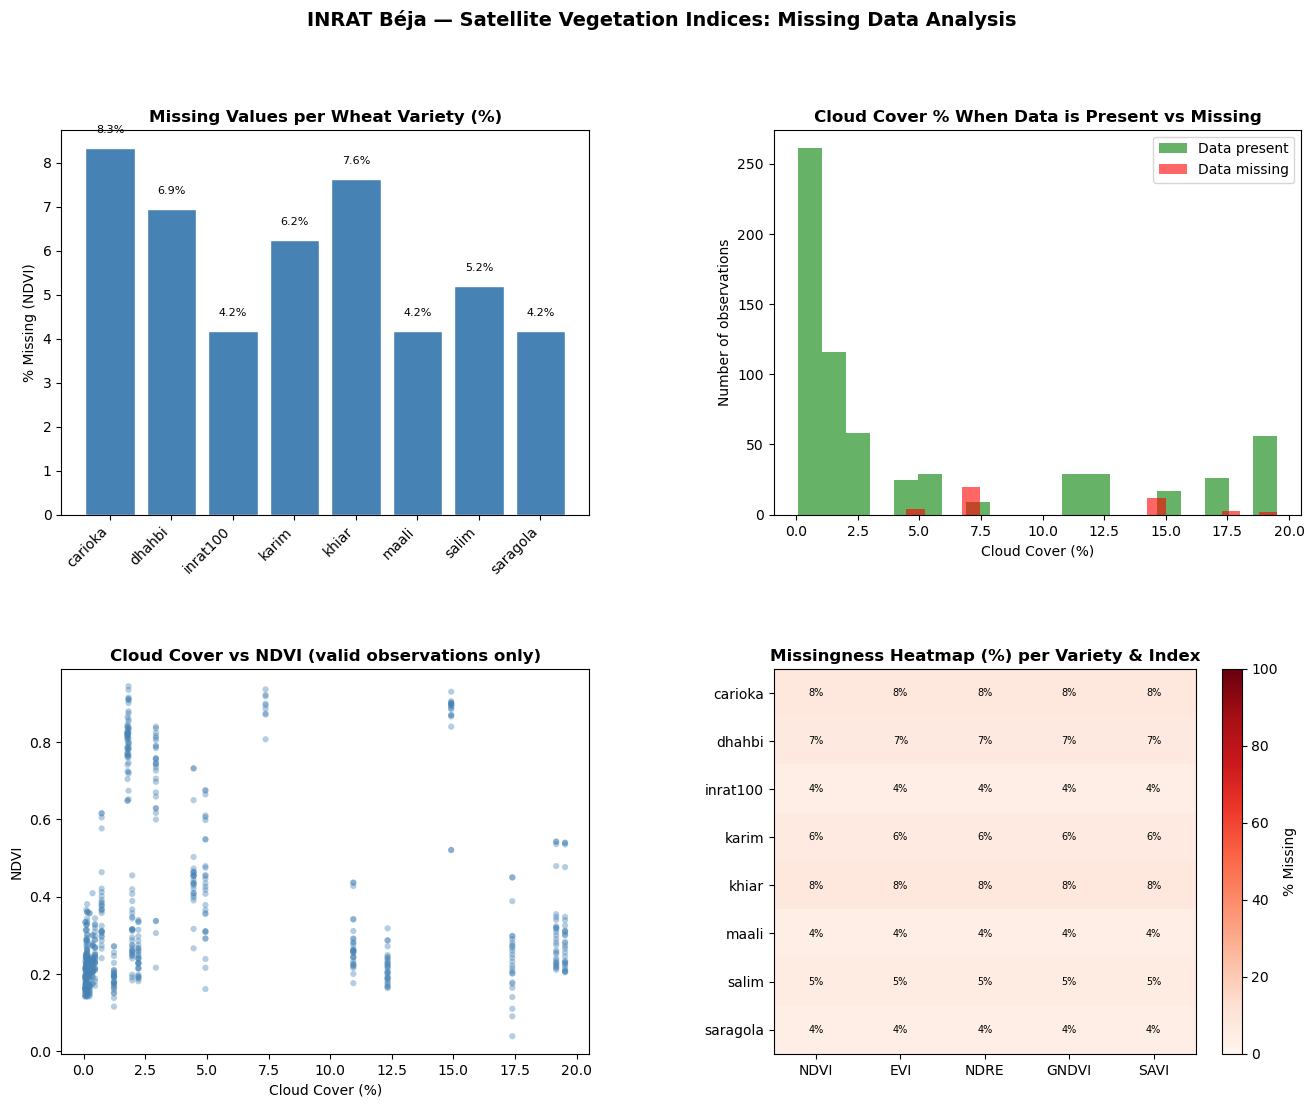

Saved to reports/missing_data_analysis.png


In [16]:
#cell 7
fig = plt.figure(figsize=(16, 12))
fig.suptitle('INRAT Béja — Satellite Vegetation Indices: Missing Data Analysis', 
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Plot 1: Missing % per variety
ax1 = fig.add_subplot(gs[0, 0])
varieties = sorted(master_df['variety'].unique())
missing_pcts = []
for v in varieties:
    subset = master_df[master_df['variety'] == v]
    pct = subset['NDVI'].isna().sum() / len(subset) * 100
    missing_pcts.append(pct)

bars = ax1.bar(varieties, missing_pcts, color='steelblue', edgecolor='white')
ax1.set_title('Missing Values per Wheat Variety (%)', fontweight='bold')
ax1.set_ylabel('% Missing (NDVI)')
ax1.set_xticklabels(varieties, rotation=45, ha='right')
for bar, pct in zip(bars, missing_pcts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

# Plot 2: Cloud cover when missing vs present
ax2 = fig.add_subplot(gs[0, 1])
missing_mask = master_df['NDVI'].isna()
cloud_missing = master_df[missing_mask]['Nuages_%'].dropna()
cloud_present = master_df[~missing_mask]['Nuages_%'].dropna()

ax2.hist(cloud_present, bins=20, alpha=0.6, color='green', label='Data present')
ax2.hist(cloud_missing, bins=20, alpha=0.6, color='red', label='Data missing')
ax2.set_title('Cloud Cover % When Data is Present vs Missing', fontweight='bold')
ax2.set_xlabel('Cloud Cover (%)')
ax2.set_ylabel('Number of observations')
ax2.legend()

# Plot 3: Scatter cloud cover vs NDVI
ax3 = fig.add_subplot(gs[1, 0])
valid = master_df.dropna(subset=['NDVI', 'Nuages_%'])
ax3.scatter(valid['Nuages_%'], valid['NDVI'], 
            alpha=0.4, c='steelblue', edgecolors='none', s=20)
ax3.set_title('Cloud Cover vs NDVI (valid observations only)', fontweight='bold')
ax3.set_xlabel('Cloud Cover (%)')
ax3.set_ylabel('NDVI')

# Plot 4: Missingness heatmap
ax4 = fig.add_subplot(gs[1, 1])
index_cols = ['NDVI', 'EVI', 'NDRE', 'GNDVI', 'SAVI']
heatmap_data = []
for v in varieties:
    subset = master_df[master_df['variety'] == v]
    row = [subset[col].isna().sum() / len(subset) * 100 for col in index_cols]
    heatmap_data.append(row)

heatmap_array = np.array(heatmap_data)
im = ax4.imshow(heatmap_array, cmap='Reds', aspect='auto', vmin=0, vmax=100)
ax4.set_xticks(range(len(index_cols)))
ax4.set_xticklabels(index_cols)
ax4.set_yticks(range(len(varieties)))
ax4.set_yticklabels(varieties)
ax4.set_title('Missingness Heatmap (%) per Variety & Index', fontweight='bold')
plt.colorbar(im, ax=ax4, label='% Missing')

for i in range(len(varieties)):
    for j in range(len(index_cols)):
        ax4.text(j, i, f'{heatmap_array[i,j]:.0f}%',
                ha='center', va='center', fontsize=7,
                color='white' if heatmap_array[i,j] > 50 else 'black')

plt.savefig('../reports/missing_data_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to reports/missing_data_analysis.png")

In [17]:
#cell 8
cloud_when_missing = master_df[missing_mask]['Nuages_%'].dropna()
cloud_when_present = master_df[~missing_mask]['Nuages_%'].dropna()

t_stat, p_value = stats.ttest_ind(cloud_when_missing, cloud_when_present)

print("=== STATISTICAL PROOF: CLOUD COVER CAUSES MISSINGNESS ===")
print()
print(f"Average cloud cover when NDVI is PRESENT: {cloud_when_present.mean():.1f}%")
print(f"Average cloud cover when NDVI is MISSING: {cloud_when_missing.mean():.1f}%")
print()
print(f"T-test p-value: {p_value:.6f}")
if p_value < 0.05:
    print("STATISTICALLY SIGNIFICANT (p < 0.05)")
    print("Cloud cover is a statistically proven cause of missing vegetation indices")
    print("This confirms MNAR (Missing Not At Random) pattern")
    print("Pipeline will use Nuages_% as primary decision feature for imputation strategy")
else:
    print("Not statistically significant")

=== STATISTICAL PROOF: CLOUD COVER CAUSES MISSINGNESS ===

Average cloud cover when NDVI is PRESENT: 4.9%
Average cloud cover when NDVI is MISSING: 10.6%

T-test p-value: 0.000000
STATISTICALLY SIGNIFICANT (p < 0.05)
Cloud cover is a statistically proven cause of missing vegetation indices
This confirms MNAR (Missing Not At Random) pattern
Pipeline will use Nuages_% as primary decision feature for imputation strategy


In [19]:
master_df.to_csv("../data/processed/master_beja.csv", index=False)
print("Saved")
print(f"Shape: {master_df.shape}")

Saved
Shape: (696, 9)
